In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import pickle
import math
import statistics as stat
from tqdm import tqdm
from scipy.io import loadmat
from os.path import exists

# --- CONFIGURATION ---

TC_DATA_DIR = os.getenv("TC_DATA_DIR", "../data") # Note: points to parent data folder if inside 'analysis'
MPI_DIR = os.path.join(TC_DATA_DIR, "mpi_out")

print(f"Loading data from: {TC_DATA_DIR}")

# Helper to load data safely
def get_data_path(filename):
    path = os.path.join(TC_DATA_DIR, filename)
    if not os.path.exists(path):
        print(f"Warning: {filename} not found at {path}")
    return path

In [62]:
plt.rcParams.update({
"text.usetex": True,
'font.size' : 20,
"font.family": "lmodern",
"ps.distiller.res": 10000})
plt.rcParams['figure.dpi'] = 250
plt.rcParams['savefig.dpi'] = 250
plt.style.use('seaborn-pastel')
plt.rcParams["figure.figsize"] = [5,4]
plt.rcParams['axes.linewidth'] = 1.5 
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18

In [ ]:
# Loading the observed data
basin_names = ["WP", "SP", "SI", "SA", "NI", "NA", "EP"]

data = []
for basin in basin_names:
    filename = f"IBTrACS_TRMM_SHIPS_{basin}_LFR.nc"
    try:
        ds = xr.open_dataset(get_data_path(filename))
        data.append(ds)
    except FileNotFoundError:
        print(f"Skipping {basin}: File not found.")

# Load topography
topography = loadmat(get_data_path("data_grd.mat"))

In [6]:
def extract_datas(data_storms, data_topography):
    
    longi=np.array(data_topography["x"])[0]
    #longi.flatten()
    lati=np.array(data_topography["y"])[0]
    # lati.flatten()
    heights=np.array(data_topography["Z"])  # table of heights len(lati)=10801*len(longi)=21601
    
    
    maxwspd=np.array([])
    av_R34=np.array([])
    RMW=np.array([])
    
    av_H=np.array([])
    std_H=np.array([])
    max_H=np.array([])
    T=np.array([])
    radius=10
    #MPI_s=np.array([])
    for k in range (len(data_storms)):
        data=data_storms[k]
        for i in tqdm(range (len(np.array(data.maxwspd)))):
            b=True
            j=0
            while b==True:
                #print("i", i,"j",j)
                if np.mean(np.array(data.R34)[i][j])>10**5:
                    #print("s: ",np.array(data.azirainrate)[i][j-1])
                    #print("j: ", j)
                    if j!=0:
                        
#                         lat_storm=np.array(data.lat)[i][j-1]
#                         lon_storm=np.array(data.lon)[i][j-1]
                        #print(lat_storm)
                        #print(lon_storm)
                        if np.isnan(np.array(data.maxwspd)[i][j-1])==False and np.isnan(np.array(data.RMW)[i][j-1])==False and np.isnan(np.mean(np.array(data.R34)[i][j-1]))==False and np.array(data.RMW)[i][j-1]!=0 and np.mean(np.array(data.R34)[i][j-1])>0:
#                             yr=pd.Timestamp(np.array(data.isotime)[i][j-1]).year
#                             mth=pd.Timestamp(np.array(data.isotime)[i][j-1]).month
#                             basin=np.array(data.basin)[i][j-1]
                            

                            maxwspd=np.append(maxwspd,np.array(data.maxwspd)[i][j-1])
                            #MPI_s=np.append(MPI_s,mpi)
                            av_R34=np.append(av_R34,np.mean(np.array(data.R34)[i][j-1]))
                            
                            RMW=np.append(RMW,np.array(data.RMW)[i][j-1])
                                #av_H=np.append(av_H,avh)
                                #std_H=np.append(std_H,stdh)
                                #max_H=np.append(max_H,maxh)
                                #T=np.append(T,np.array(data.RSST)[i][j-1])
                                    #print("(lat,lon): ",lat_storm, lon_stor
                    b=False
                else:
                    j+=1

    #converting in m.s^(-1), the variables were in knts before
    maxwspd=0.514*np.array(maxwspd) 
    #converting nautical miles in km
    av_R34=1.852*np.array(av_R34)
    RMW=1.852*np.array(RMW)
   
            
    #sat_wv_P=np.array([Clausius_Clap(t) for t in T] )
    return maxwspd,av_R34, RMW#, av_H, std_H,max_H, sat_wv_P
    

In [7]:
def Clausius_Clap(T): #T in celsius
    return 6.1094*np.exp(17.625*T/(243.04+T)) #"from Improved Magnus` form approximation of saturation vapor pressure"1997 Pressure in hPa

In [8]:
def av_Height(lat,lon,d_lat,d_lon,d_heights, radius): #function that computes the average height the associated standard deviation and the maximum heihgt of the environment within a certain radius
    
    #set all the negative values (depth of sea) to sea altitude:0
    d_heights[d_heights<0]=0
    
    #finding the corresponding storm latitude and longitude index in the data tables
    ind_lat=[idx for idx,val in enumerate(d_lat) if val>lat][0]
    ind_lon=[idx for idx,val in enumerate(d_lon) if val>lon][0]

    
    #find the boundary index of the radius km environment (rectangle) around the TC landfall
    ind_lat_up=0
    ind_lat_down=0
    ind_lon_up=0
    ind_lon_down=0
    dist_lat_up=0
    dist_lat_down=0
    dist_lon_up=0
    dist_lon_down=0
    
    i=0
    b1=False
    ind_lon_tmp=ind_lon
    while dist_lon_up<radius:
        loc1=(d_lat[ind_lat],d_lon[ind_lon_tmp+i])
        if ind_lon_tmp+i==len(d_lon)-1:
            ind_lon_tmp=-i-1
            b1=True
            print("boundary 1")
        loc2=(d_lat[ind_lat],d_lon[ind_lon_tmp+i+1])
        dist_lon_up=dist_lon_up+hs.haversine(loc1,loc2)
        i+=1
    ind_lon_up=ind_lon_tmp+i
    
    
    i=0
    b2=False
    ind_lon_tmp=ind_lon
    while dist_lon_down<radius:
        
        loc1=(d_lat[ind_lat],d_lon[ind_lon_tmp-i])
        if ind_lon_tmp-i==0:
            ind_lon_tmp=len(d_lon)+i
            b2=True
            print("boundary 2")
        loc2=(d_lat[ind_lat],d_lon[ind_lon_tmp-i-1])
        dist_lon_down=dist_lon_down+hs.haversine(loc1,loc2)
        i+=1
    ind_lon_down=ind_lon_tmp-i
    
    #print(ind_lon_down)
    i=0
    b3=False
    ind_lat_tmp=ind_lat
    while dist_lat_up<radius:
        
        loc1=(d_lat[ind_lat_tmp+i],d_lon[ind_lon])
        if ind_lat_tmp+i==len(d_lat)-1:
            ind_lat_tmp=-i-1
            b3=True
            print("boundary 3")
        loc2=(d_lat[ind_lat_tmp+i+1],d_lon[ind_lon])
        dist_lat_up=dist_lat_up+hs.haversine(loc1,loc2)
        i+=1
    ind_lat_up=ind_lat_tmp+i
    
    
    #print(ind_lat_up)
    i=0
    b4=False
    ind_lat_tmp=ind_lat
    while dist_lat_down<radius:
        
        loc1=(d_lat[ind_lat_tmp-i],d_lon[ind_lon])
        if ind_lat_tmp-i==0:
            ind_lat_tmp=len(d_lat)+i
            b4=True
            print("boundary 4")
        loc2=(d_lat[ind_lat_tmp-i-1],d_lon[ind_lon])
        dist_lat_down=dist_lat_down+hs.haversine(loc1,loc2)
        i+=1
    ind_lat_down=ind_lat_tmp-i
    
    #heights in the surrounding environment 
    
    if b1==False and b2==False and b3==False and b4==False: 
        heights_env= d_heights[ind_lat_down:ind_lat_up,ind_lon_down:ind_lon_up] 
    
        loc_storm=(lat,lon)
        heights_radius=[]
        for i in range (len(heights_env)):
            for j in range (len(heights_env[i])):
                loc_grid=(d_lat[ind_lat_down+i],d_lon[ind_lon_down+j])
                if hs.haversine(loc_storm,loc_grid)<radius:
                    heights_radius.append(heights_env[i][j])

        #print(heights_radius)
        av_height=np.mean(np.array(heights_radius))
        std_height=np.std(np.array(heights_radius))
        max_height=np.amax(np.array(heights_radius))
        boo=True
    else :
        print("Anomaly when processing the data, one value has been set to NaN")
        av_height=np.nan
        std_height=np.nan
        max_height=np.nan
        boo=False
    return av_height, std_height, max_height, boo

In [10]:
#maxwspd,av_R34,RMW, av_H,std_H,max_H, sat_wv_P=extract_datas(data, topography)
maxwspd, av_R34, RMW=extract_datas(data, topography)
table_34=0.514*np.array([34]*len(maxwspd)) #table of 34 knots wind speed of length(maxwspd)
#print(np.array(np.array(maxwspd)/np.array(table_34))[np.array(np.array(maxwspd)/np.array(table_34))==0])

100%|███████████████████████████████████████| 372/372 [00:00<00:00, 4628.82it/s]


In [195]:
table_34=0.514*np.array([34]*len(maxwspd)) #table of 34 knots wind speed of length(maxwspd)

In [11]:
#extracting alpha distribution

alpha_s=[]
alpha_s2=[]
for i in tqdm(range(len(maxwspd))):
#     a = symbols('a')
#     expr = Eq(maxwspd[i]/table_34[i]-(av_R34[i]/RMW[i])**a)
#     sol = solve(expr)
#     alpha_s.append(sol)
    
    a2=np.log(maxwspd[i]/table_34[i])/np.log(av_R34[i]/RMW[i])
    if math.isinf(a2):
        print(maxwspd[i])
        print(av_R34[i]/RMW[i])
    alpha_s2.append(a2)
alpha_s2=np.array(alpha_s2)

  0%|                                                   | 0/413 [00:00<?, ?it/s]/var/folders/61/8ccz1ryj18v0xdgwrft4y2qc0000gn/T/ipykernel_1788/146386578.py:11: RuntimeWarning: divide by zero encountered in double_scalars
  a2=np.log(maxwspd[i]/table_34[i])/np.log(av_R34[i]/RMW[i])
100%|█████████████████████████████████████| 413/413 [00:00<00:00, 108258.71it/s]

17.990000000000002
1.0
20.560000000000002
1.0


In [12]:
index_neg=np.array(np.argwhere(alpha_s2<0).flatten())
index_inf=np.array(np.argwhere(alpha_s2==math.inf).flatten())
alpha_pos=np.array(alpha_s2.copy())
for ind in np.concatenate((index_neg,index_inf)):
    av_R34[ind]=-1
    RMW[ind]=-1
    alpha_pos[ind]=-1
    #sat_wv_P[ind]=-1
    #MPI_s[ind]=-1
#     max_H[ind]=-1
#     av_H[ind]=-1
#     std_H[ind]=-1
av_R34=av_R34[av_R34!=-1]
RMW=RMW[RMW!=-1]
alpha_pos=alpha_pos[alpha_pos!=-1]
#sat_wv_P=sat_wv_P[sat_wv_P!=-1]
#MPI_s=MPI_s[MPI_s!=-1]
# max_H=max_H[max_H!=-1]
# av_H=av_H[av_H!=-1]
# std_H=std_H[std_H!=-1]

In [160]:
indexs=np.array(np.argwhere(sat_wv_P>10**4))
indexs.flatten()
for ind in indexs:
    sat_wv_P[ind]=-1
    av_R34[ind]=-1
    RMW[ind]=-1
    alpha_pos[ind]=-1
    maxwspd[ind]=-1
av_R34=av_R34[av_R34!=-1]
RMW=RMW[RMW!=-1]
alpha_pos=alpha_pos[alpha_pos!=-1]
sat_wv_P=sat_wv_P[sat_wv_P!=-1]

In [236]:
for ind in np.concatenate((index_neg,index_inf)):
    maxwspd[ind]=-1

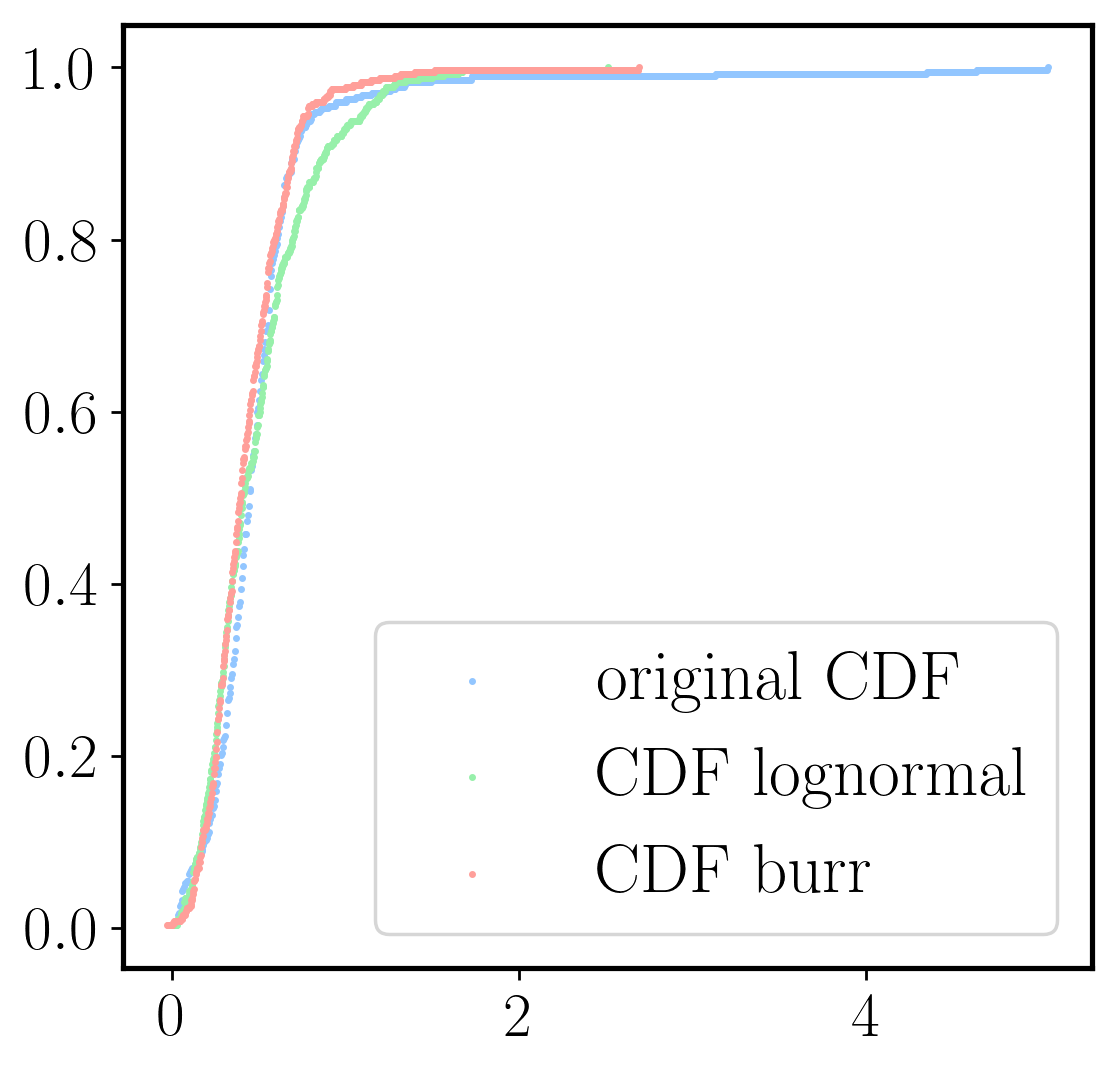

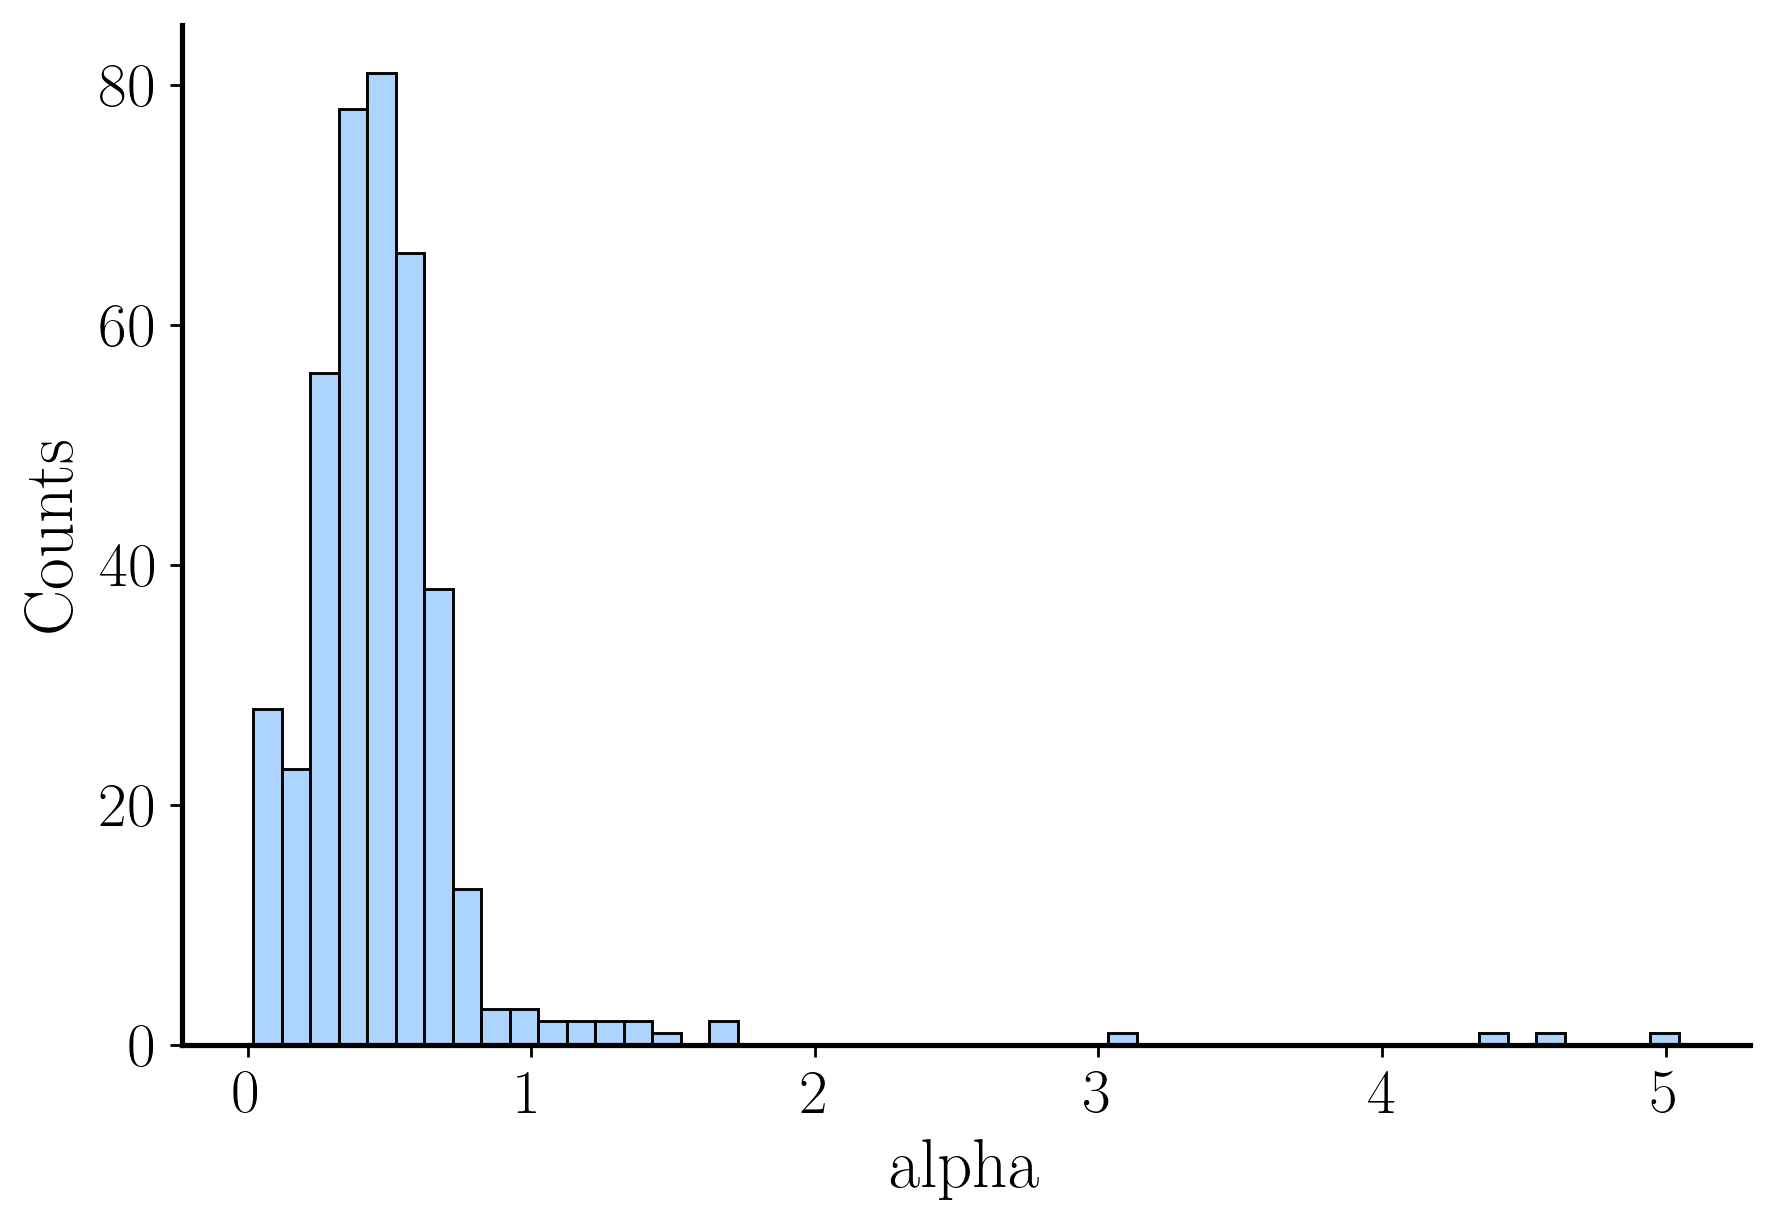

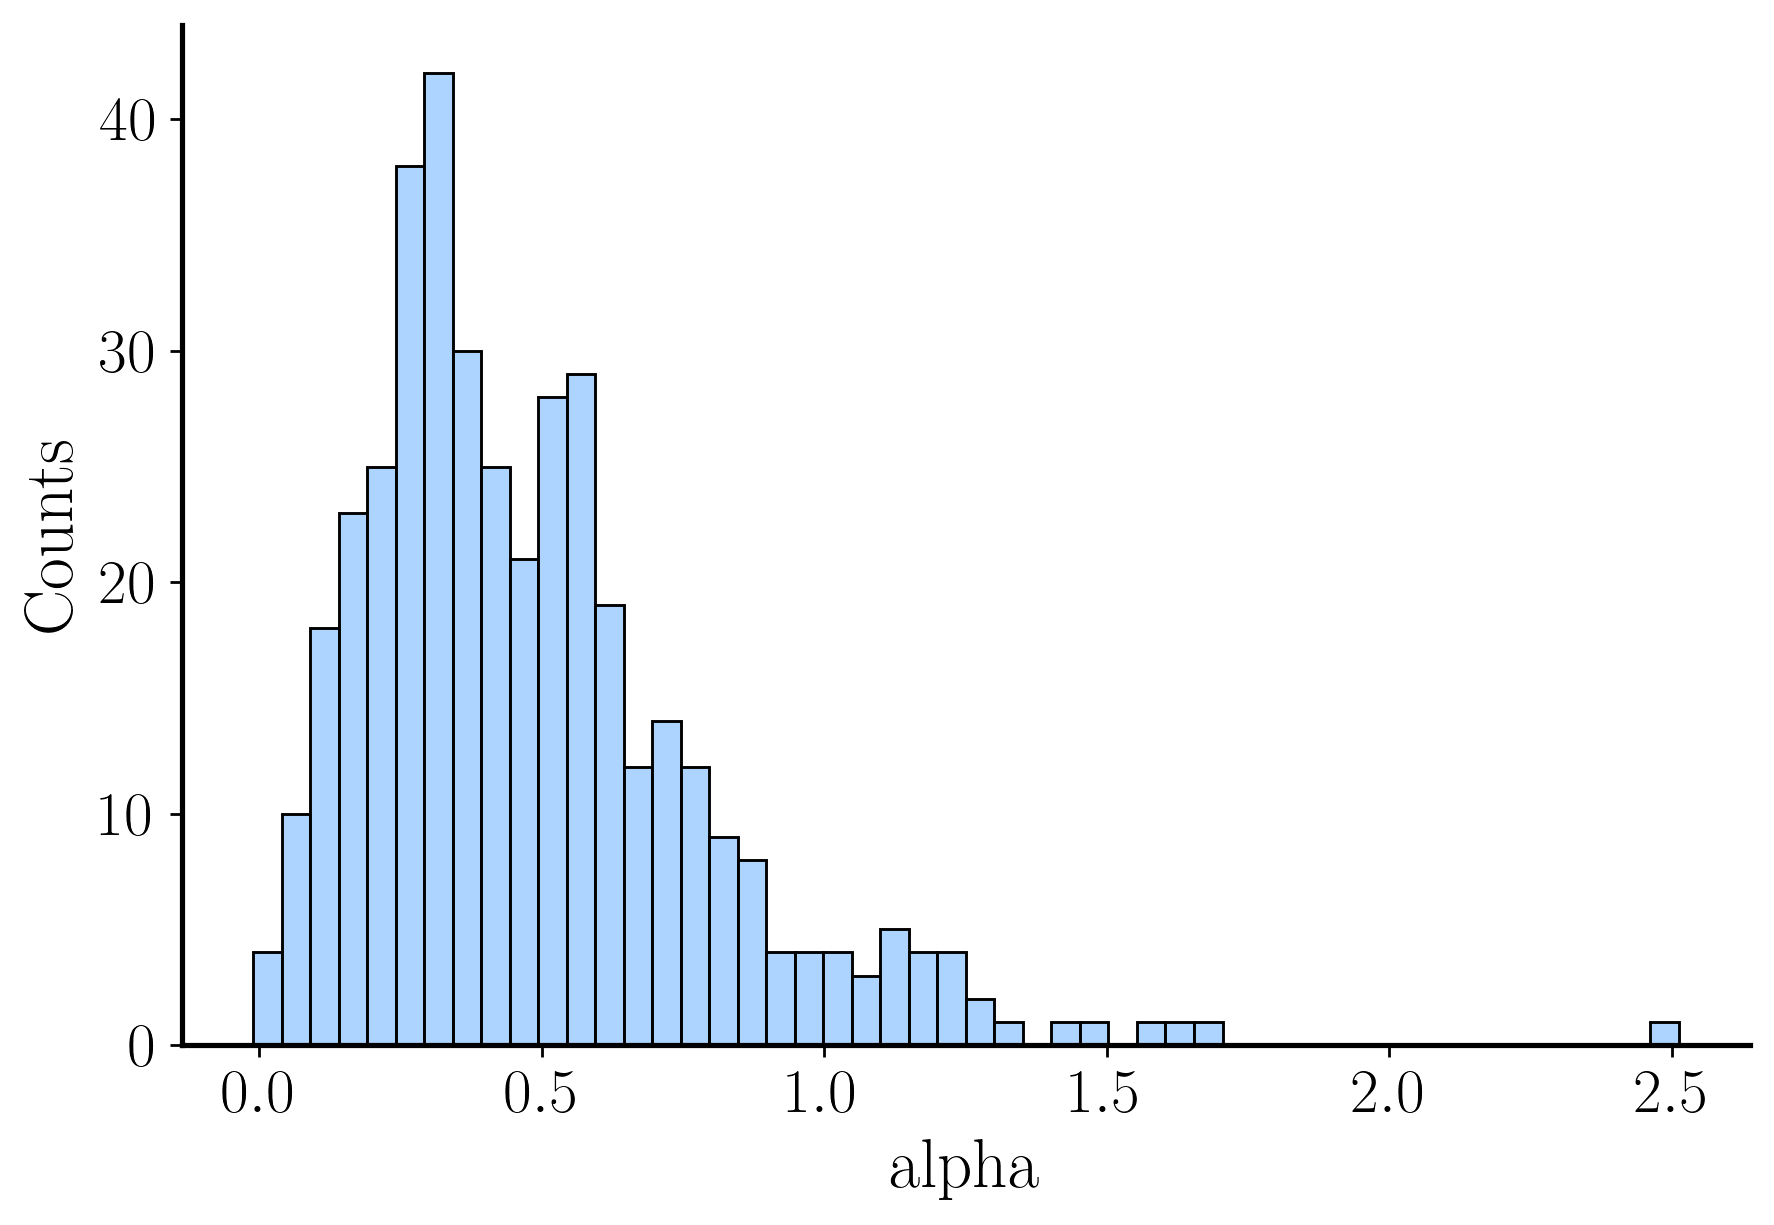

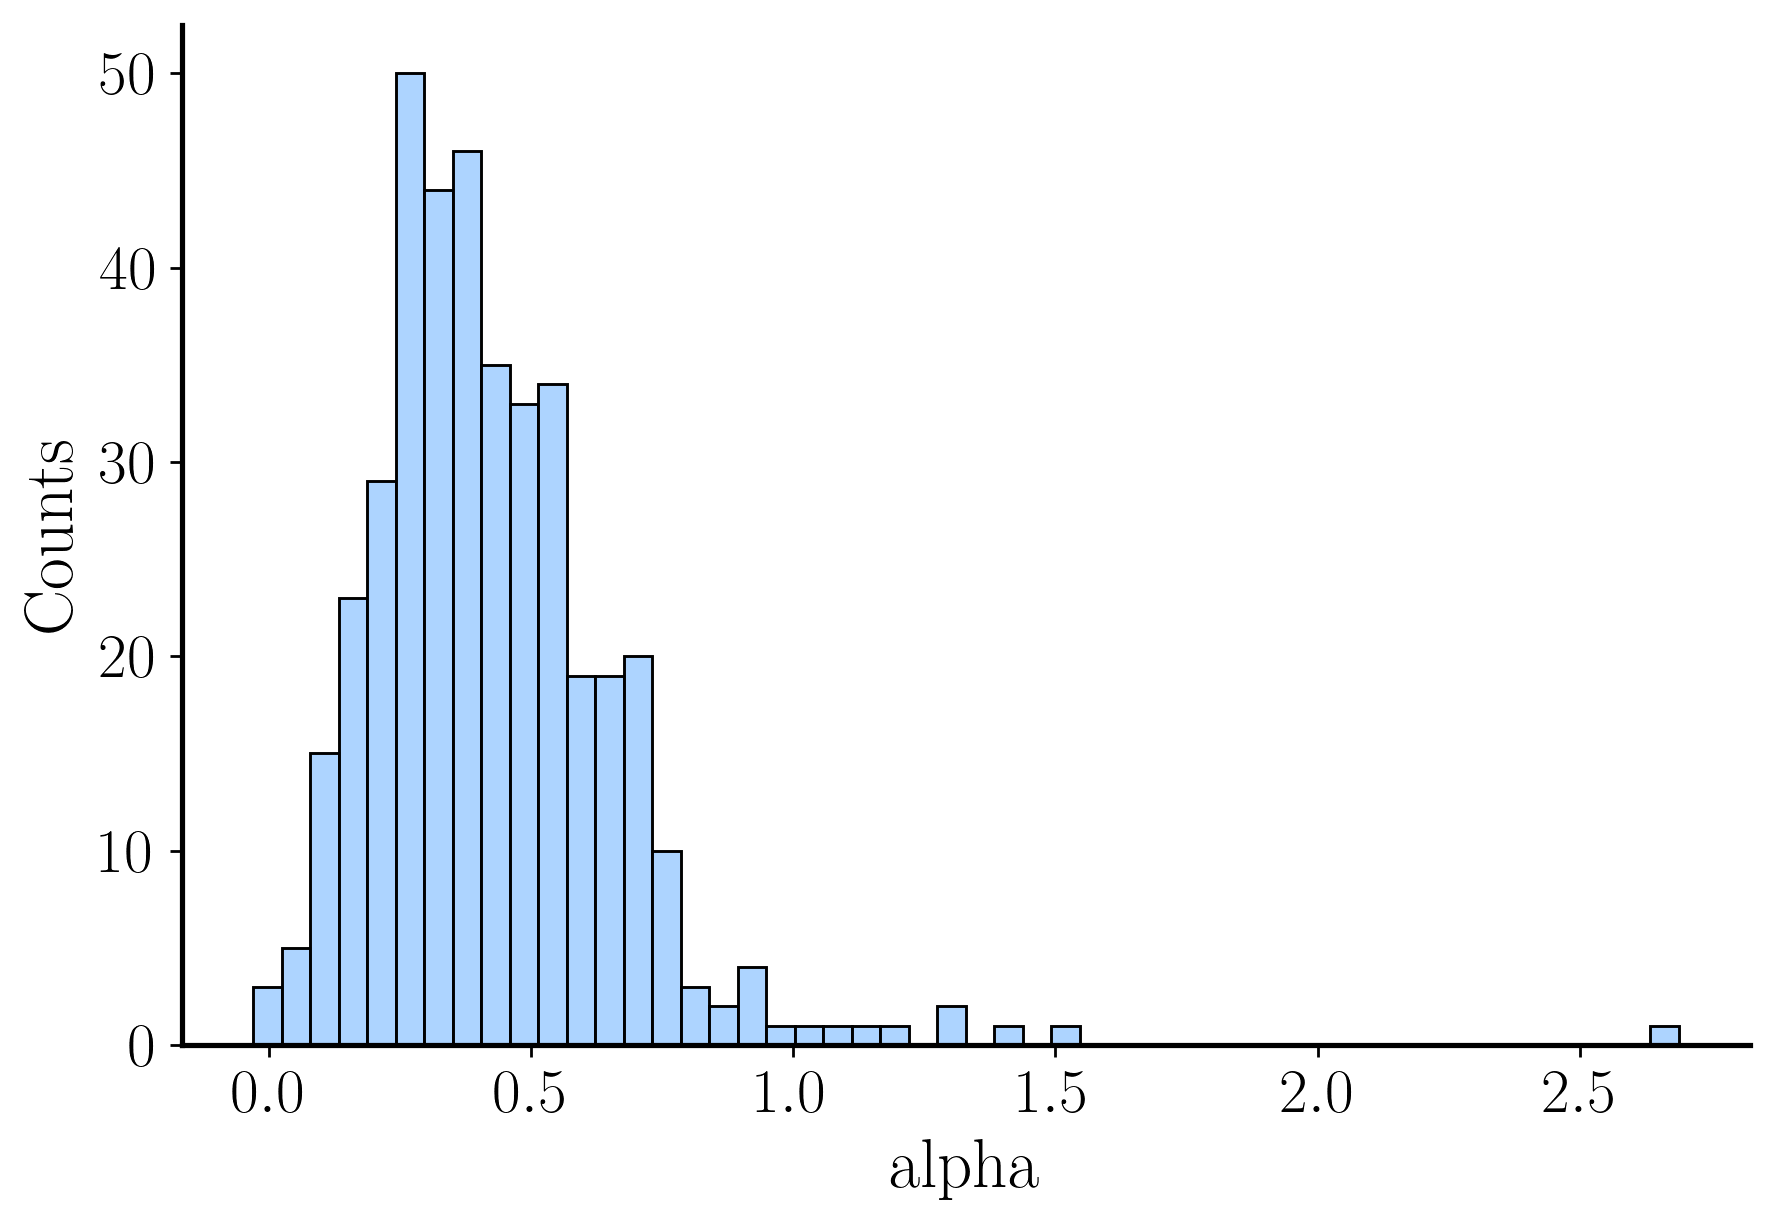

In [9]:
alpha_pos=alpha_s2[alpha_s2>0] # negative values should not appear, we attribute to errors in measurements so delete the data
alpha_pos=alpha_pos[alpha_pos<math.inf] # infinite would appear if Rmax=R34 (only 2 storms in the data)
#alpha_pos=alpha_pos[alpha_pos<1] #the majority of the values lie for alpha <1, this suggests that values where alpha>1 could come from errors in measurements


  
alpha_lognorm=lognorm.rvs(s=0.44431369829381895,loc=-0.1604776602702505,scale=0.5835246701049612, size=len(alpha_pos))
#alpha_lognorm2=lognorm.rvs(s=0.44431369829381895,loc=-0.1604776602702505,scale=0.5835246701049612, size=len(alpha_pos))
alpha_burr=burr.rvs(4.8254278183524315, 0.4856593590267311, -0.042452790196895296, 0.601076373081717,size=len(alpha_pos))

count, bins_count = np.histogram(alpha_pos, bins=1000)
count2,bins_count2=np.histogram(alpha_lognorm,bins=1000)
count2bis,bins_count2bis=np.histogram(alpha_burr,bins=1000)

# finding the PDF of the histogram using count values
pdf = count / sum(count)
pdf2=count2/sum(count2)
pdf2bis=count2bis/sum(count2bis)
  
# using numpy np.cumsum to calculate the CDF
# We can also find using the PDF values by looping and adding
cdf = np.cumsum(pdf)
cdf2=np.cumsum(pdf2)
cdf2bis=np.cumsum(pdf2bis)
  
# plotting PDF and CDF
#plt.scatter(bins_count[1:], pdf, color="red", label="PDF", s=1)
plt.scatter(bins_count[1:], cdf, label="original CDF ", s=1)
plt.legend()
#plt.scatter(bins_count2[1:], pdf2, color="red", label="PDF", s=1)
plt.scatter(bins_count2[1:], cdf2, label="CDF lognormal", s=1)
plt.legend()
#plt.scatter(bins_count2[1:], pdf2bis, color="red", label="PDF", s=1)
plt.scatter(bins_count2bis[1:], cdf2bis, label="CDF burr", s=1)
plt.legend()

g1=sns.displot(data=alpha_pos, kind="hist", bins = 50, aspect = 1.5)
g1.set(xlabel ="alpha", ylabel = "Counts", title ='')
g1=sns.displot(data=alpha_lognorm, kind="hist", bins = 50, aspect = 1.5)
g1.set(xlabel ="alpha", ylabel = "Counts", title ='')
g1=sns.displot(data=alpha_burr, kind="hist", bins = 50, aspect = 1.5)
g1.set(xlabel ="alpha", ylabel = "Counts", title ='')

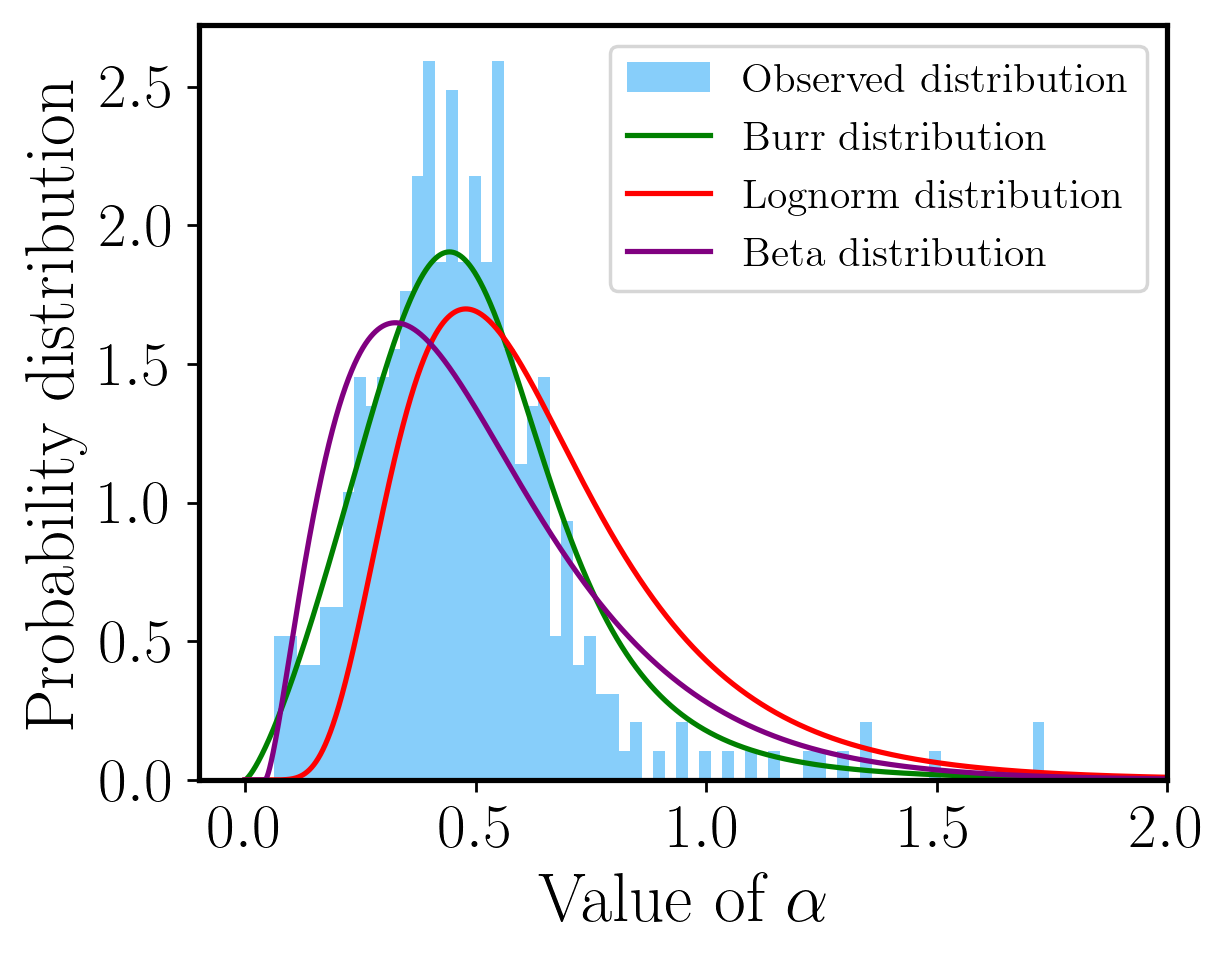

In [65]:
plt.figure(1)
# alpha_burr=burr.rvs(4.8254278183524315, 0.4856593590267311, -0.042452790196895296, 0.601076373081717,size=50000)
# alpha_burr=ss.burr(4.8254278183524315, 0.4856593590267311, -0.042452790196895296, 0.601076373081717)
alpha_burr=ss.burr(4.8254278183524315, 0.4856593590267311,0, 0.601076373081717)
# alpha_lognorm=lognorm.rvs(0.44431369829381895, -0.1604776602702505, 0.5835246701049612,size=50000)
alpha_lognorm=ss.lognorm(0.44431369829381895, 0, 0.5835246701049612)
alpha_beta=ss.beta(2.5135378453106902, 102683231294.89734, 0.04405697651582263, 19130156181.88018)
plt.hist(alpha_pos[alpha_pos>0.059],bins=200, alpha=1,density=True,color='lightskyblue', label="Observed distribution", histtype='bar')
x=np.linspace(0,5,500000)
plt.plot(x, alpha_burr.pdf(x), color='green', label='Burr distribution')
plt.plot(x, alpha_lognorm.pdf(x),color='red', label='Lognorm distribution')
plt.plot(x, alpha_beta.pdf(x),color='purple', label='Beta distribution')

plt.legend(prop={'size': 12})
plt.xlim(-0.1,2)
plt.xlabel(r"Value of $\alpha$")
plt.ylabel("Probability distribution")
#plt.hist(alpha_burr,bins=100,alpha=1,density=True,histtype='step',color='green')
#plt.hist(alpha_lognorm,bins=100,alpha=1,density=True,histtype='step',color='red')
plt.show()

(4.325577321688757, 0.6383248230949732, 0.0048381231112144514, 0.5145488711712045)
(0.48179537818147, -0.05042050400953482, 0.49110150939728425)
(2.5135378453106902, 102683231294.89734, 0.04405697651582263, 19130156181.88018)
{'burr': {'c': 4.325577321688757, 'd': 0.6383248230949732, 'loc': 0.0048381231112144514, 'scale': 0.5145488711712045}}


,sumsquare_error,aic,bic,kl_div
burr,1.099658,1200.444681,-2245.312088,inf
lognorm,3.011514,1348.613273,-1861.389705,inf
beta,4.129388,1726.048606,-1733.260673,inf
gamma,36.461999,1041.334349,-896.278357,inf


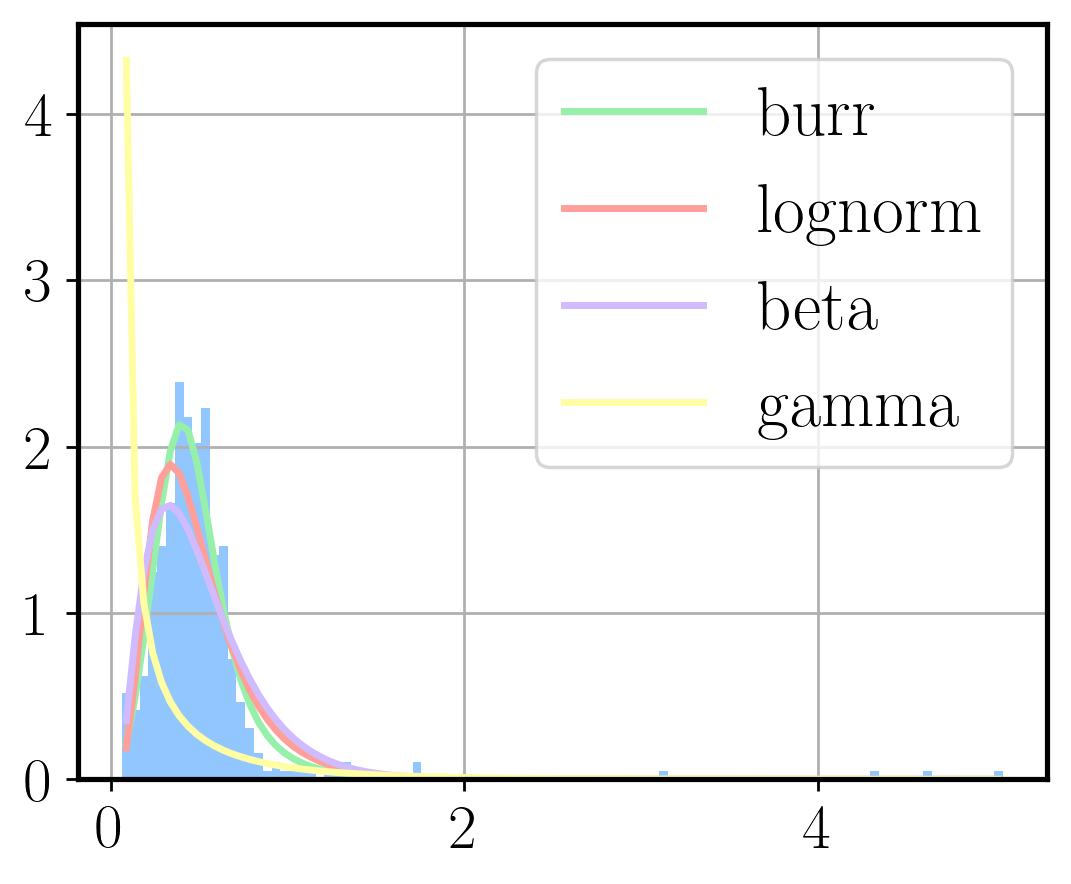

In [64]:
#print(alpha_pos)
f=Fitter(alpha_pos[alpha_pos>0.059], distributions=['gamma','lognorm', 'beta', 'burr'])
f.fit()
print(f.fitted_param['burr'])
print(f.fitted_param['lognorm'])
print(f.fitted_param['beta'])
print(f.get_best())
f.summary()
#ax.grid(False)
#f.fitted_pdf

In [15]:
###study the correlations between alpha and Rmax, R34 and maswspd

indexs=np.array(np.argwhere(alpha_s2<0))
indexs=indexs.flatten()
indexs2=np.array(np.argwhere(alpha_s2>10**10))
indexs2=indexs2.flatten()
#print(indexs2)
#print(indexs)
indexs=np.concatenate((indexs,indexs2))
alpha_ss=alpha_s2


for ind in indexs:
    maxwspd[ind]=-1
    av_R34[ind]=-1
    RMW[ind]=-1
    alpha_ss[ind]=-1

log_maxwspd=np.log(maxwspd[maxwspd!=-1])
log_av_R34=np.log(av_R34[av_R34!=-1])
log_RMW=np.log(RMW[RMW!=-1])
log_alpha_ss=np.log(alpha_ss[alpha_ss!=-1])

0.12398310061166175
-0.5088053504980606
0.4434436583263596


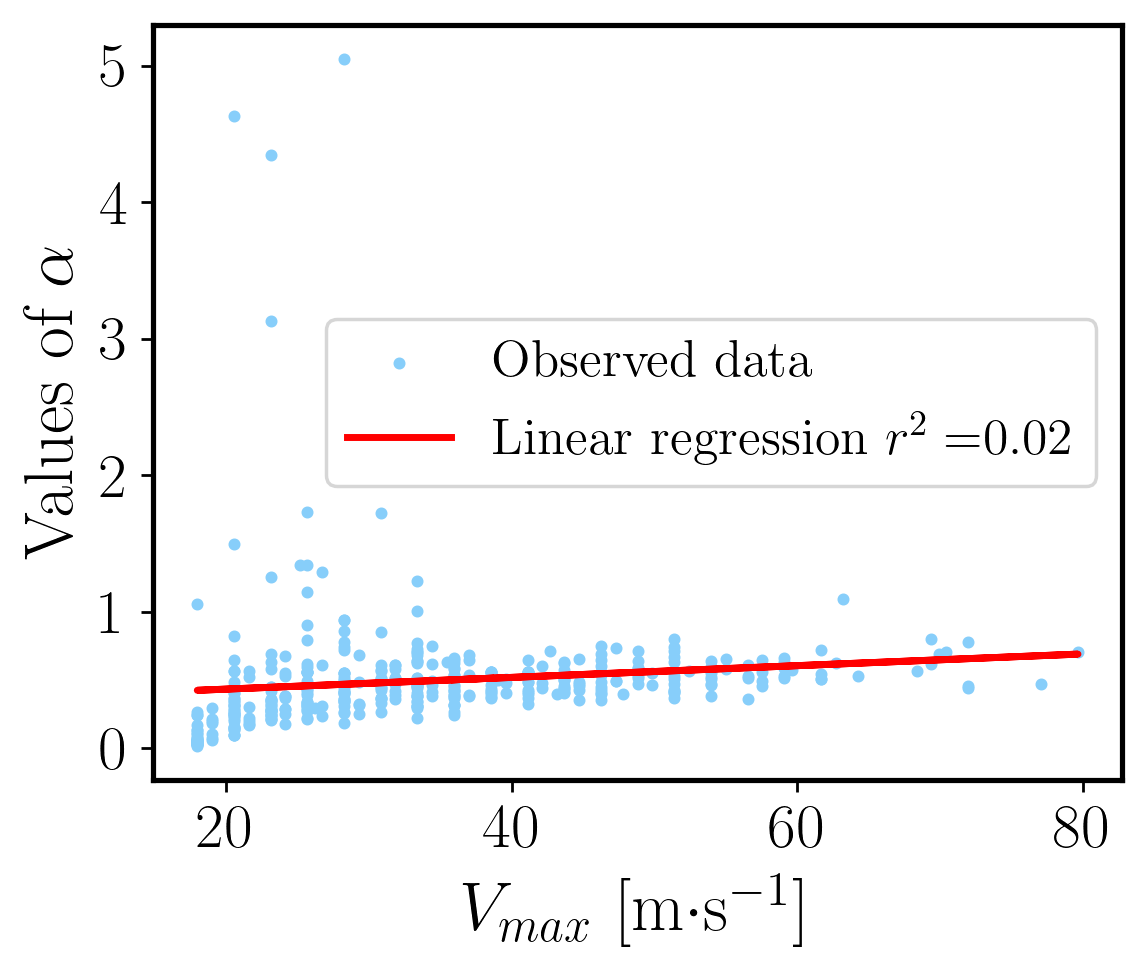

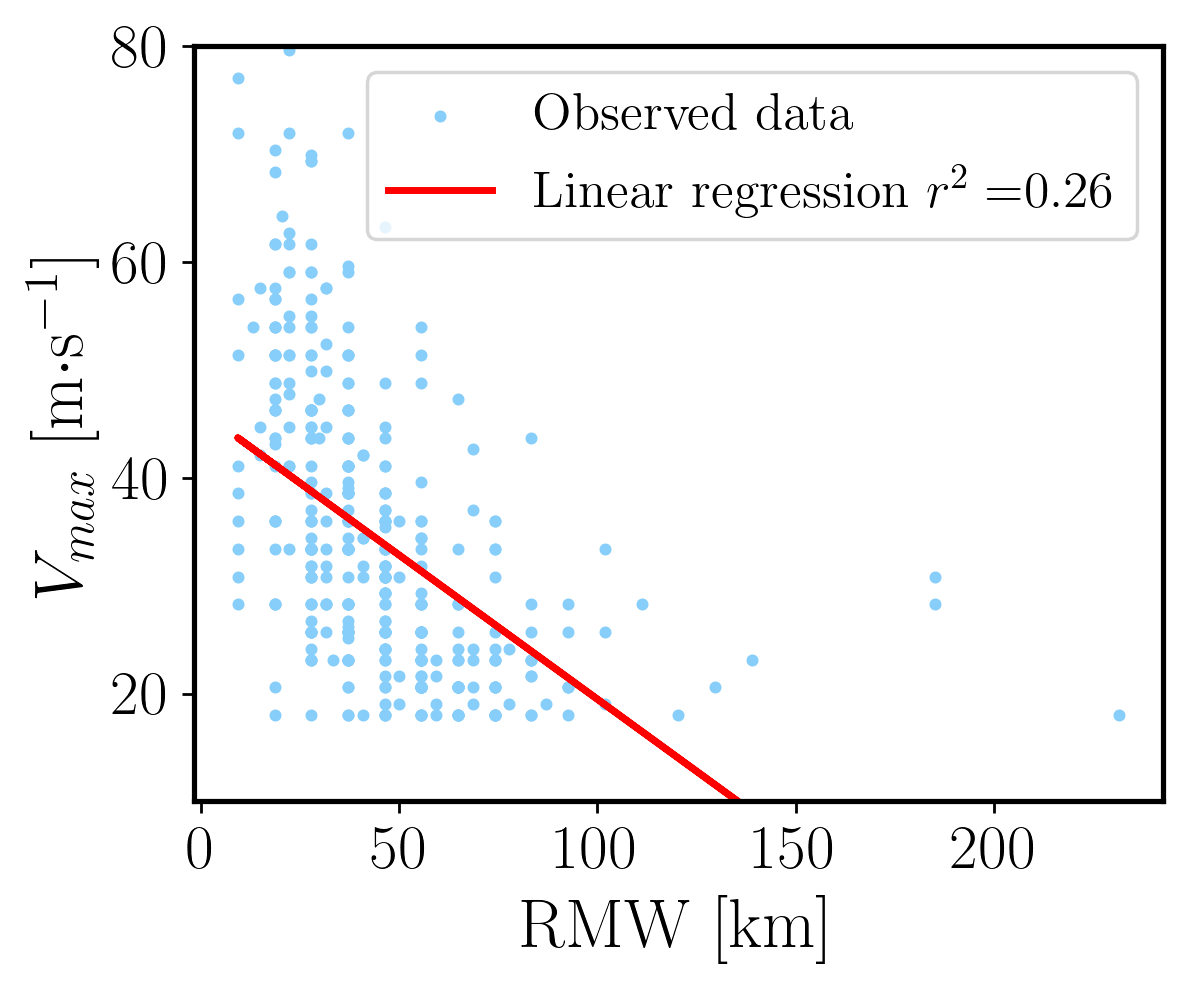

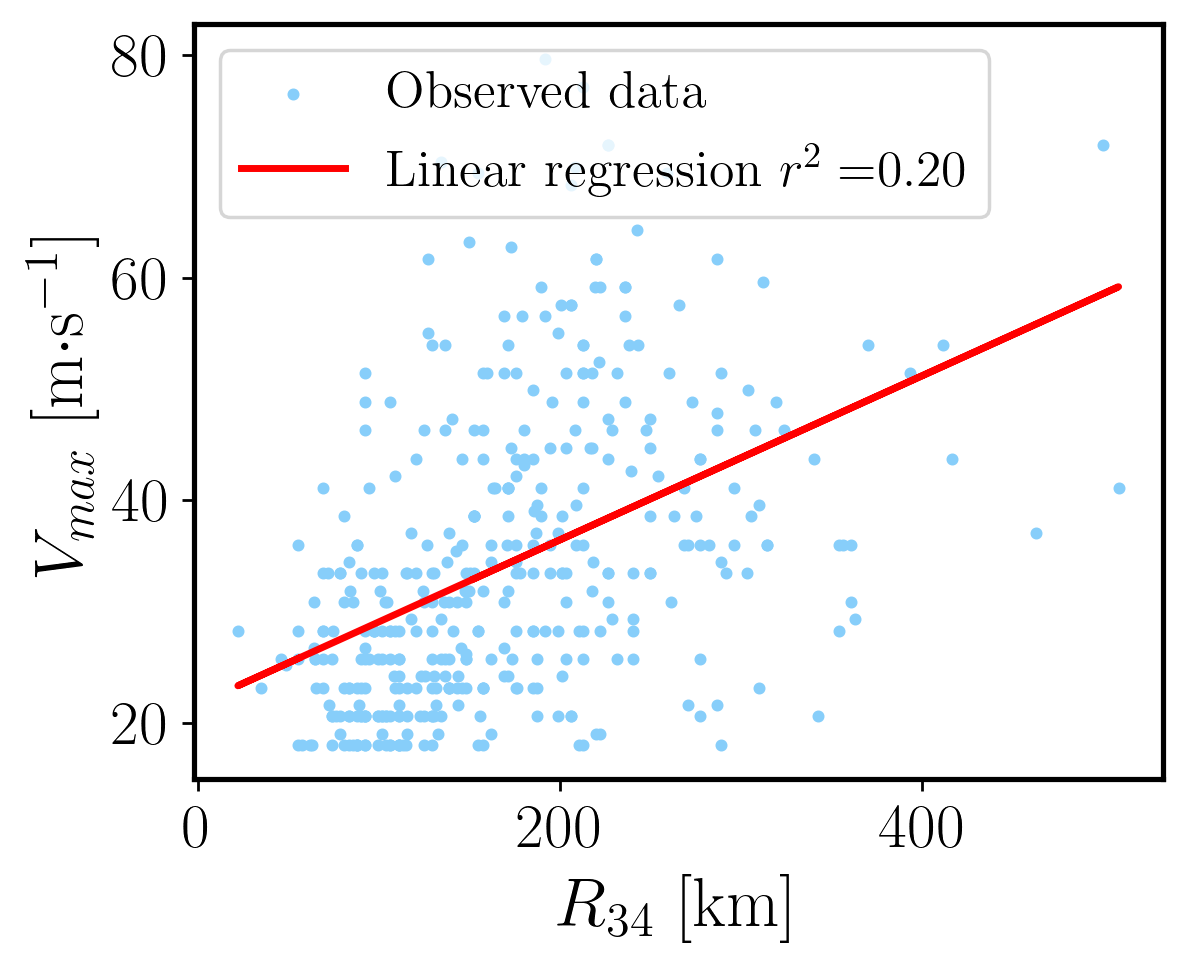

In [266]:
#print(log_alpha_ss)

m1, b1,r_1,p1,std1 = stats.linregress(av_R34,alpha_pos)
m2, b2,r_2,p2,std2 = stats.linregress(RMW,alpha_pos)
m3, b3,r_3,p3,std3 = stats.linregress(maxwspd[maxwspd!=-1],alpha_pos)
#m4, b4,r_4,p4,std4 = stats.linregress(MPI_s,alpha_pos)
m5, b5,r_5,p5,std5 = stats.linregress(RMW,maxwspd[maxwspd!=-1])
m6, b6,r_6,p6,std6 = stats.linregress(av_R34,maxwspd[maxwspd!=-1])
m7, b7,r_7,p7,std7 = stats.linregress(av_R34, RMW)
y_fit1=m1*av_R34+b1
y_fit2=m2*RMW+b2
y_fit3=m3*maxwspd[maxwspd!=-1]+b3
#y_fit4=m4*MPI_s+b4
y_fit5=m5*RMW+b5
y_fit6=m6*av_R34+b6
y_fit7=m7*av_R34+b7

print(r_3)
print(r_5)
print(r_6)

# plt.figure(1)
# plt.scatter(av_R34,alpha_pos, marker='o', s=6,  label="Observed data", color='lightskyblue')

# plt.plot(av_R34, y_fit1, linewidth=2,  label="Linear regression $r^2=$%.2f"%r_1**2,color='red')
# plt.xlabel(r"Averaged $R_{34}$ [km]")
# plt.ylabel(r"Values of $\alpha$ ")
# # plt.legend(prop={'size': 15})


plt.figure(3)
plt.scatter(maxwspd[maxwspd!=-1],alpha_pos, marker='o', s=6, color="lightskyblue", label="Observed data")
#plt.scatter(log_P,log_maxrain, marker='o', s=2, color="black", label="Observed data")
plt.plot(maxwspd[maxwspd!=-1], y_fit3, linewidth=2, color='red', label="Linear regression $r^2=$%.2f"%r_3**2)
plt.xlabel("$V_{max}$ [m$\cdot$s$^{-1}$]")
plt.ylabel(r"Values of $\alpha$")
plt.legend(prop={'size': 15})

# plt.figure(4)
# plt.scatter(MPI_s,alpha_pos, marker='o', s=2, color="black", label="Observed data")
# #plt.scatter(log_P,log_maxrain, marker='o', s=2, color="black", label="Observed data")
# plt.plot(MPI_s, y_fit4, linewidth=1, color='black', label="Linear regression $r^2=$%.2f"%r_4**2)
# plt.xlabel("Average height")
# plt.ylabel(r"$\alpha$")
# plt.legend(prop={'size': 15})

plt.figure(4)
plt.scatter(RMW,maxwspd[maxwspd!=-1], marker='o', s=6, color="lightskyblue", label="Observed data")
#plt.scatter(log_P,log_maxrain, marker='o', s=2, color="black", label="Observed data")
plt.plot(RMW, y_fit5, linewidth=2, color='red', label="Linear regression $r^2=$%.2f"%r_5**2)
plt.xlabel("RMW [km]")
plt.ylabel(r"$V_{max}$ [m$\cdot$s$^{-1}$]")
plt.ylim(10,80)
plt.legend(prop={'size': 15})


plt.figure(5)
plt.scatter(av_R34,maxwspd[maxwspd!=-1], marker='o', s=6, color="lightskyblue", label="Observed data")
#plt.scatter(log_P,log_maxrain, marker='o', s=2, color="black", label="Observed data")
plt.plot(av_R34, y_fit6, linewidth=2, color='red', label="Linear regression $r^2=$%.2f"%r_6**2)
plt.xlabel("$R_{34}$ [km]")
plt.ylabel(r"$V_{max}$ [m$\cdot$s$^{-1}$]")
plt.legend(prop={'size': 15})


# plt.figure(6)
# plt.scatter(av_R34,RMW, marker='o', s=2, color="lightskyblue", label="Observed data")
# #plt.scatter(log_P,log_maxrain, marker='o', s=2, color="black", label="Observed data")
# plt.plot(av_R34, y_fit7, linewidth=1, color='red', label="Linear regression $r^2=$%.2f"%r_7**2)
# plt.xlabel("$R_{34}$ [km]")
# plt.ylabel(r"$V_{max}$ [m$\cdot$s$^{-1}$]")
# plt.legend(prop={'size': 15})




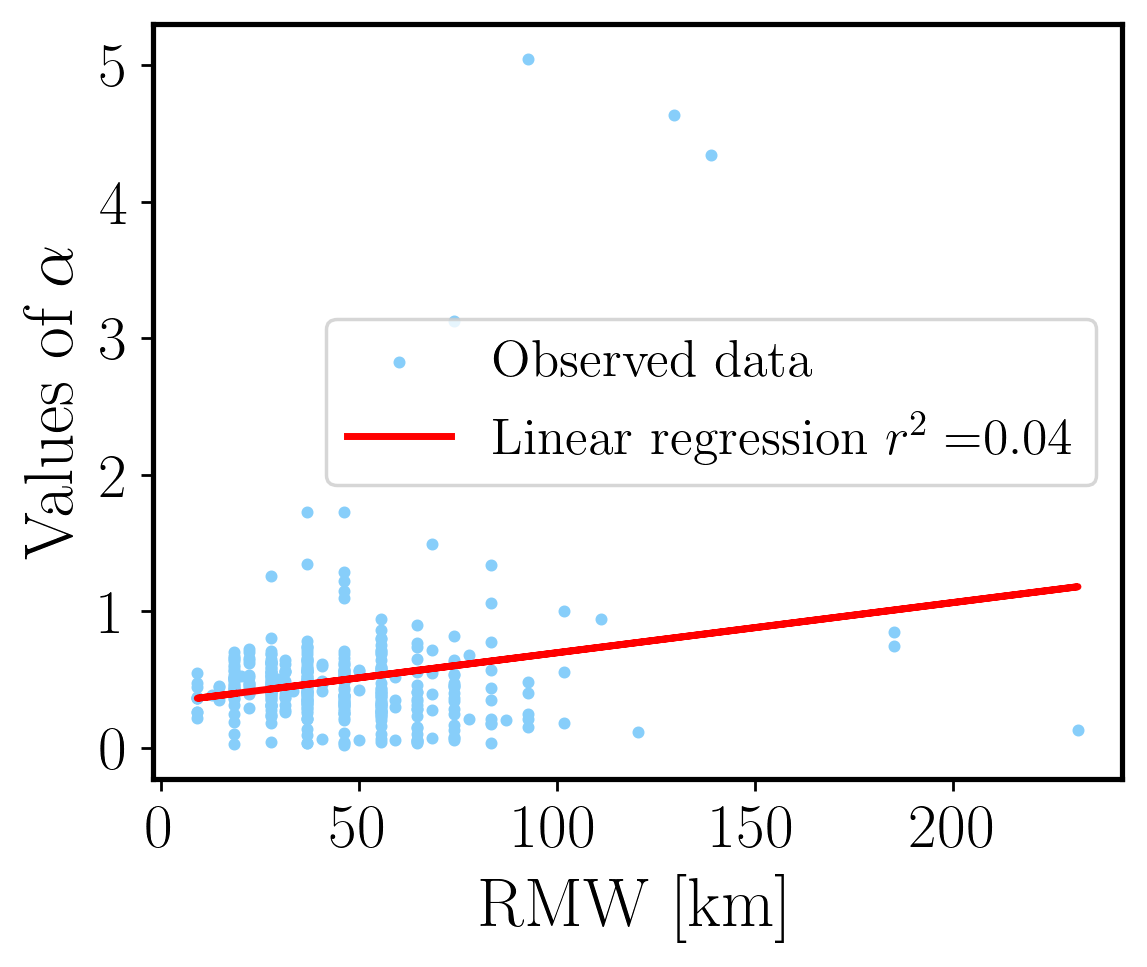

In [98]:
plt.figure(2)
plt.scatter(RMW,alpha_pos, marker='o', s=6, color="lightskyblue", label="Observed data")

plt.plot(RMW, y_fit2, linewidth=2, color='red', label="Linear regression $r^2=$%.2f"%r_2**2)
plt.xlabel("RMW [km]")
plt.ylabel(r"Values of $\alpha$ ")
plt.legend(prop={'size': 15})

